In [1]:
#2d double integrator collision avoidance ipopt 
#position and velocity with control being the acceleration 
using Pkg
Pkg.activate(".")

  Activating project at `~/Research/polynomial_opt`


In [2]:
using Test 
using LinearAlgebra
using SparseArrays
using Plots
using ForwardDiff
import lazy_nlp_qd 

In [3]:
#indexing 

function create_idx(nx,nu,N)
    # This function creates some useful indexing tools for Z 
    # x_i = Z[idx.x[i]]
    # u_i = Z[idx.u[i]]

    #Z vector is [x1, u1, x2, u2, x3, u3, x4...]

    nz = (N-1) * nu + (N) * nx # length of Z 


    x = [(i-1)*nx .+ (1:nx) for i=1:N]

    u = [(i-1)*nu .+ (nx*N+1:nx*N+nu) for i=1:N]

    return (nx=nx,nu=nu,N=N,nz = nz,x= x,u = u)
end

create_idx (generic function with 1 method)

In [4]:
# Discrete dynamics
h = 0.1   # time step

#for one timestep
A = [1 0 h 0; 0 1 0 h; 0 0 1 0; 0 0 0 1]

B = [0.5*h*h 0; 0 0.5*h*h; h 0; 0 h]

4×2 Matrix{Float64}:
 0.005  0.0
 0.0    0.005
 0.1    0.0
 0.0    0.1

In [5]:
#number in state (position (x,y) and velocity (vx, vy))
nx = 4

#number of controls (acceleration (ax, ay))
nu = 2

2

In [6]:
#Tfinal = 5.0 # final time (testing )

Tfinal = 5.0

N = Int(Tfinal/h)+1    # number of time steps
thist = Array(range(0,h*(N-1), step=h));

In [7]:
idx = create_idx(nx,nu,N)

(nx = 4, nu = 2, N = 51, nz = 304, x = UnitRange{Int64}[1:4, 5:8, 9:12, 13:16, 17:20, 21:24, 25:28, 29:32, 33:36, 37:40  …  165:168, 169:172, 173:176, 177:180, 181:184, 185:188, 189:192, 193:196, 197:200, 201:204], u = UnitRange{Int64}[205:206, 207:208, 209:210, 211:212, 213:214, 215:216, 217:218, 219:220, 221:222, 223:224  …  287:288, 289:290, 291:292, 293:294, 295:296, 297:298, 299:300, 301:302, 303:304, 305:306])

In [8]:
# Initial conditions 
#works 
#x0 = [1.0; 1.0; 0.0; 0.0]

#for this initial condition, there should be two global solutions 
#for some reason the local solver converges to a point of local infeasibility, even with infinite controls
x0 = [0.0; 1.0; 0.0; 0.0]
#x0 = [0.1; 1.0; 0.0; 0.0]


x_goal = [0.0; -1.0; 0.0; 0.0]

u0 = [0.1; 0.1]

#obstacle pose
o_x = 0
o_y = 0

#bound constraints 
umin = -1.5
umax = 1.5

#increase the limits
#umin = -2.5
#umax = 2.5

1.5

In [9]:
function create_initial_states(idx)

    #slacks are part of nz now 
    z0 = zeros(idx.nz)

    z0[idx.x[1]] = x0

    #will just rollout the initial state with no control input as the initial guess trajectory 
    for i=1:N-1

        z0[idx.x[i+1]] = A*z0[idx.x[i]] + B*u0
        z0[idx.u[i]] = u0

    end

    return z0
    
end

create_initial_states (generic function with 1 method)

In [10]:
z0 = create_initial_states(idx) 

304-element Vector{Float64}:
 0.0
 1.0
 0.0
 0.0
 0.0005000000000000001
 1.0005
 0.010000000000000002
 0.010000000000000002
 0.0020000000000000005
 1.0019999999999998
 ⋮
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1
 0.1

In [11]:
xtraj_initial = reshape(z0[1:nx*N], 4, N)  

4×51 Matrix{Float64}:
 0.0  0.0005  0.002  0.0045  0.008  …  1.058  1.1045  1.152  1.2005  1.25
 1.0  1.0005  1.002  1.0045  1.008     2.058  2.1045  2.152  2.2005  2.25
 0.0  0.01    0.02   0.03    0.04      0.46   0.47    0.48   0.49    0.5
 0.0  0.01    0.02   0.03    0.04      0.46   0.47    0.48   0.49    0.5

In [12]:
# Cost weights
Q = Array(10.0*I(idx.nx))
R = 0.1 #Array(1.0*I(1))
Qn = Array(1000.0*I(idx.nx))

4×4 Matrix{Float64}:
 1000.0     0.0     0.0     0.0
    0.0  1000.0     0.0     0.0
    0.0     0.0  1000.0     0.0
    0.0     0.0     0.0  1000.0

In [13]:
#these are linear 
function dynamics_constraints(params, Z::Vector)


    idx, N = params.idx, params.N

    c_dynamics = zeros(eltype(Z), nx, N-1)

    for i=1:N-1

        c_dynamics[:,i] = A*Z[idx.x[i]] + B*Z[idx.u[i]] - Z[idx.x[i+1]]

    end

    return vec(c_dynamics)
    
end

dynamics_constraints (generic function with 1 method)

In [14]:
function equality_constraint(params, Z)

    return [
                #initial condition 
                Z[idx.x[1]] - x0; 

                #add a goal constraint (maybe not a good idea since it can make the problem infeasible...)
                #Z[idx.x[end]] - x_goal; 

                #dynamics constraints 
                dynamics_constraints(params, Z)

            ]
            
end

equality_constraint (generic function with 1 method)

In [15]:
function inequality_constraint(params, Z::Vector)

    #collision constraint 
    
    idx, N = params.idx, params.N

    object_pose = [o_x; o_y]
    
    collision = zeros(eltype(Z), N)

    for i=1:N

        collision[i] = (norm(Z[idx.x[i][1:2]] - object_pose))^2

    end
    
    return collision

end

inequality_constraint (generic function with 1 method)

In [16]:
x_goal 

4-element Vector{Float64}:
  0.0
 -1.0
  0.0
  0.0

In [17]:
#LQR cost
#here goal is to drive the system down to zero

function cost(params, Z::Vector)

    idx, N = params.idx, params.N

    J = 0 

    for i=1:N-1

        xi = Z[idx.x[i]]
        
        ui = Z[idx.u[i]]

        J += 0.5*(xi-x_goal)'*Q*(xi-x_goal) #+ 0.5*ui'*R*ui

    end

    xn = Z[idx.x[N]]

    J += 0.5*(xn)'*Qn*xn

    return J 

    
end

cost (generic function with 1 method)

In [18]:
#radius of the obstacle
obstacle_r = 0.75

0.75

In [19]:
#bounds for the inequality constraints
#lower bound on the collision constraint
#the 0.1 determines the size of the circle (r)

c_l = ones(N)*obstacle_r
c_u = Inf*ones(N)

51-element Vector{Float64}:
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
  ⋮
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf

In [20]:
#bound the controls 
x_l = -Inf*ones(idx.nz)
x_u = Inf*ones(idx.nz)

304-element Vector{Float64}:
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
  ⋮
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf
 Inf

In [21]:
#bound the controls 

for i=1:N-1

    x_l[idx.u[i]] .= umin

    x_u[idx.u[i]] .= umax

end

In [22]:
params = (N=N, idx = idx)

(N = 51, idx = (nx = 4, nu = 2, N = 51, nz = 304, x = UnitRange{Int64}[1:4, 5:8, 9:12, 13:16, 17:20, 21:24, 25:28, 29:32, 33:36, 37:40  …  165:168, 169:172, 173:176, 177:180, 181:184, 185:188, 189:192, 193:196, 197:200, 201:204], u = UnitRange{Int64}[205:206, 207:208, 209:210, 211:212, 213:214, 215:216, 217:218, 219:220, 221:222, 223:224  …  287:288, 289:290, 291:292, 293:294, 295:296, 297:298, 299:300, 301:302, 303:304, 305:306]))

In [23]:
diff_type = :auto 

:auto

In [24]:
""" we are solving the following problem:
    
minimize_x        cost(x)
subject to        c_L <= constraint(x) <= c_U
                  x_L <= x <= x_U
"""

Z = lazy_nlp_qd.fmincon_dense(cost::Function,
                           equality_constraint::Function,
                           inequality_constraint::Function,
                           x_l::Vector,
                           x_u::Vector,
                           c_l::Vector,
                           c_u::Vector,
                           z0::Vector,
                           params::NamedTuple,
                           diff_type::Symbol; 
                           tol = 1e-6,
                           c_tol = 1e-6,
                           max_iters = 1_000,
                           verbose = true)

---------checking dimensions of everything----------
---------all dimensions good------------------------
---------diff type set to :auto (ForwardDiff.jl)----
---------testing objective gradient-----------------
---------testing constraint Jacobian----------------
---------successfully compiled both derivatives-----
---------IPOPT beginning solve----------------------

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.16, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...:    62016
Number of nonzeros in inequality constraint Jacobian.:    15504
Number of nonzeros in Lagrangian Hessian..

304-element Vector{Float64}:
  0.0
  1.0
  1.0429077696606891e-23
  0.0
  0.007500000074889558
  0.9924999999257589
  0.15000000149779114
 -0.1500000014848229
  0.0300000002995328
  0.9699999997040312
  ⋮
  0.11079000575082487
  0.07996905791315533
  0.11563473607638225
  0.0772927100062483
  0.1216318063470428
  0.07529016957364267
  0.12897824760473067
  0.11560481578530894
 -0.8468750510979209

In [25]:
idx.x[1]

1:4

In [26]:
position = [Z[idx.x[i][1:2]] for i=1:N]
velocity = [Z[idx.x[i][3:4]] for i=1:N]
control = [Z[idx.u[i]] for i=1:N-1]

50-element Vector{Vector{Float64}}:
 [1.5000000149779114, -1.5000000148482289]
 [1.5000000149728256, -1.5000000146490986]
 [1.5000000149654997, -1.5000000134801452]
 [1.5000000149541621, 0.6186100396225762]
 [1.5000000149345198, 1.500000002997956]
 [1.5000000148927717, -1.331190969713993]
 [1.5000000147465138, -1.5000000143308954]
 [0.37173694791172235, -1.5000000146023664]
 [-1.500000014492314, -1.500000014274696]
 [-1.5000000147335617, -1.496962710862765]
 ⋮
 [0.10623728029302035, 0.10215067179710044]
 [0.09908416360976263, 0.10274681978199543]
 [0.09295733915462986, 0.1043829932796745]
 [0.08778139064810371, 0.1070079223096017]
 [0.0834215960147867, 0.11079000575082487]
 [0.07996905791315533, 0.11563473607638225]
 [0.0772927100062483, 0.1216318063470428]
 [0.07529016957364267, 0.12897824760473067]
 [0.11560481578530894, -0.8468750510979209]

In [27]:
position 

51-element Vector{Vector{Float64}}:
 [0.0, 1.0]
 [0.007500000074889558, 0.9924999999257589]
 [0.0300000002995328, 0.9699999997040312]
 [0.06750000067386769, 0.9324999993416572]
 [0.12000000119780087, 0.8905930491099954]
 [0.18750000187117744, 0.8592791490914361]
 [0.27000000269369057, 0.8288092942392968]
 [0.36750000366440005, 0.7841834844669329]
 [0.4743586894484007, 0.7245576745499027]
 [0.5755760598994984, 0.6499318644884872]
 ⋮
 [0.10243260779050407, -0.8978330879312223]
 [0.09581006912633676, -0.8967164293868648]
 [0.0901477379759914, -0.894564121777199]
 [0.08538910047465971, -0.8913548595895868]
 [0.08148647790664247, -0.8870566077616726]
 [0.07840080860826494, -0.8816262322246221]
 [0.07610144814948443, -0.8750095239754546]
 [0.07456500208860338, -0.8671397654565283]
 [0.07398303095451708, -0.8628594909550678]

In [28]:
#transform these vector of vector into matrices to plot 

q_traj = zeros(2, N)

v_traj = zeros(2, N)

u_traj = zeros(nu, N-1)

for i=1:N 

    q_traj[:,i] = position[i]
    v_traj[:,i] = velocity[i] 

end

for i=1:N-1

    u_traj[:,i] = control[i]

end

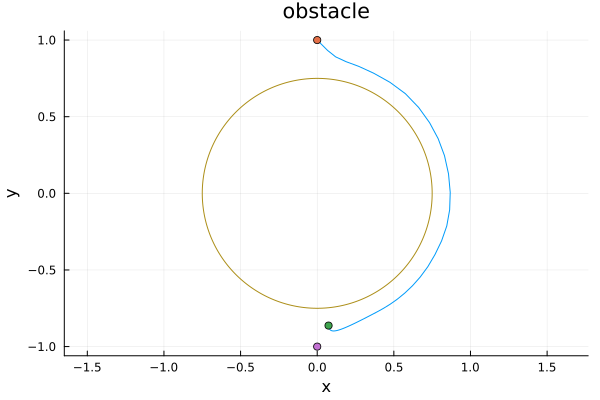

In [29]:
plot(q_traj[1,:], q_traj[2,:], label="traj", title="Collision Avoidance Trajectory")

scatter!([q_traj[1,1]], [q_traj[2,1]], label="Start")

scatter!([q_traj[1,end]], [q_traj[2,end]], label="End")

scatter!([x_goal[1]], [x_goal[2]])

#scatter!([o_x], [o_y], label="obstacle")




##############################################
# Circle parameters
r = obstacle_r                # radius
cx, cy = o_x, o_y       # center

# Parametrize the circle
θ = range(0, 2π, length=500)
x_circle = cx .+ r .* cos.(θ)
y_circle = cy .+ r .* sin.(θ)

# Plot the circle
plot!(x_circle, y_circle, aspect_ratio=1, legend=false, xlabel="x", ylabel="y", title="obstacle")

In [30]:
q_traj 

2×51 Matrix{Float64}:
 0.0  0.0075  0.03  0.0675  0.12      …   0.0761014   0.074565   0.073983
 1.0  0.9925  0.97  0.9325  0.890593     -0.87501    -0.86714   -0.862859

In [31]:
x_goal 

4-element Vector{Float64}:
  0.0
 -1.0
  0.0
  0.0

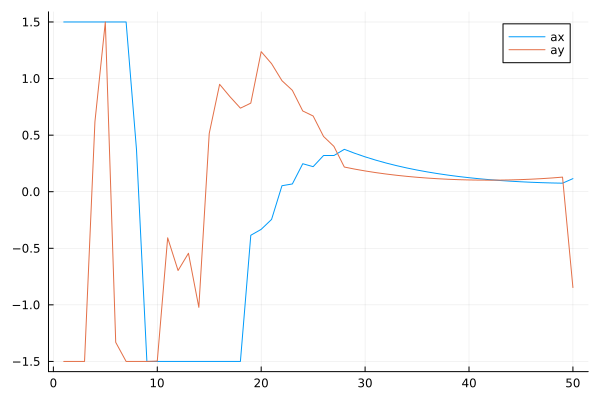

In [32]:
plot(u_traj[1,:], label="ax")
plot!(u_traj[2,:], label="ay")

In [33]:
#terminal constraint makes the problem become infeasible at certain initial conditions 
#need to find out why at the end it is going up instead of going to the goal 